# Create Predictor and save Predictor

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/home/joel/Documents/EPICS_COURSE/PROJECT/ML-epics/ex3/src/autogluon-m4-hourly'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.10.21
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2
CPU Count:          12
Pytorch Version:    2.13.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       23.49 GB / 30.96 GB (75.9%)
Disk Space Avail:   300.81 GB / 467.35 GB (64.4%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 'auto',
 'prediction_length': 48,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],

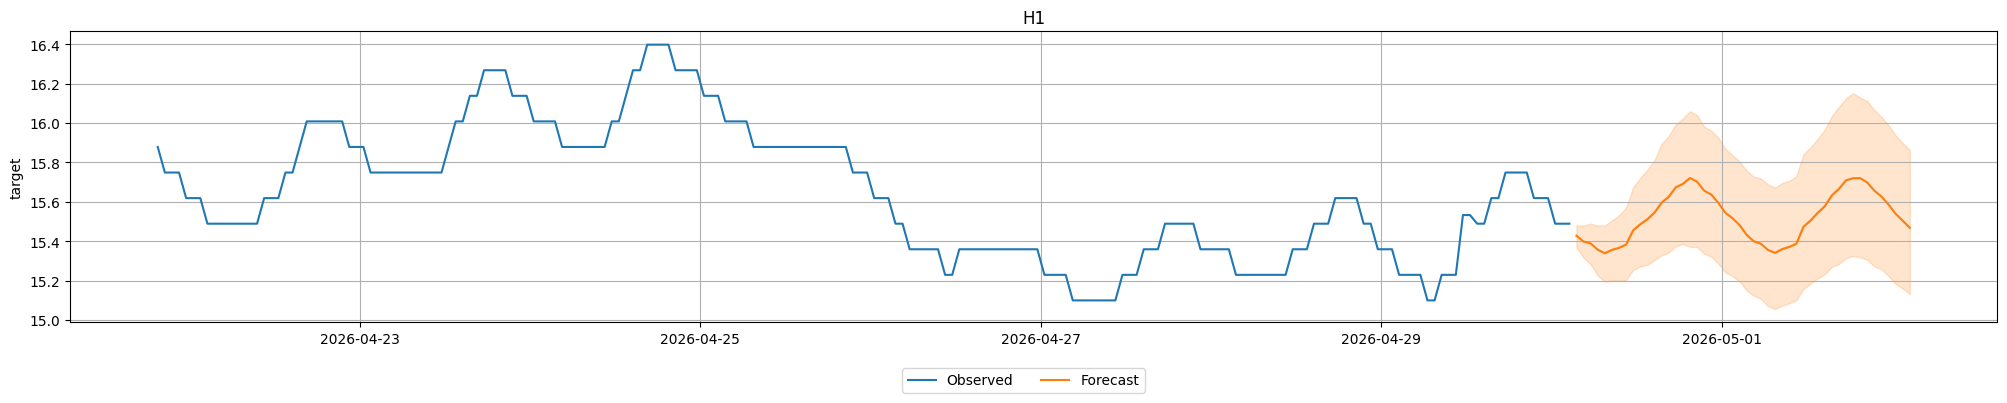

In [1]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import matplotlib.pyplot as plt

df = pd.read_csv("../april.csv")

train_data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp"
)

predictor = TimeSeriesPredictor(
    prediction_length=48,
    path="autogluon-m4-hourly",
    target="target",
    eval_metric="MASE",
)

predictor.fit(
    train_data,
    presets="best_quality",
    time_limit=600,
)

predictions = predictor.predict(train_data)
predictions.head()

# TimeSeriesDataFrame can also be loaded directly from a file
test_data = TimeSeriesDataFrame.from_path("../april.csv")

predictor.plot(test_data, predictions, quantile_levels=[0.1, 0.9], max_history_length=200)

predictor.save()


# Load Predictor

In [ ]:
predictor = TimeSeriesPredictor.load()

# Define test data (May)

In [18]:
df = pd.read_csv("../may.csv")

test_data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp"
)

test_data = test_data.slice_by_time(pd.Timestamp("2026-05-15 00:00:00"), pd.Timestamp("2026-05-23 00:00:00"))

print(test_data)

                                target
item_id timestamp                     
H1      2026-05-15 00:30:00  15.359009
        2026-05-15 01:30:00  15.359009
        2026-05-15 02:30:00  15.359009
        2026-05-15 03:30:00  15.229156
        2026-05-15 04:30:00  15.229156
...                                ...
        2026-05-22 19:30:00  17.176910
        2026-05-22 20:30:00  17.176910
        2026-05-22 21:30:00  17.176910
        2026-05-22 22:30:00  17.047058
        2026-05-22 23:30:00  17.047058

[192 rows x 1 columns]


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
Loading weights: 100%|██████████| 170/170 [00:00<00:00, 1101.30it/s]
Loaded data from: ../may.csv | Columns = 3 / 3 | Rows = 722 -> 722


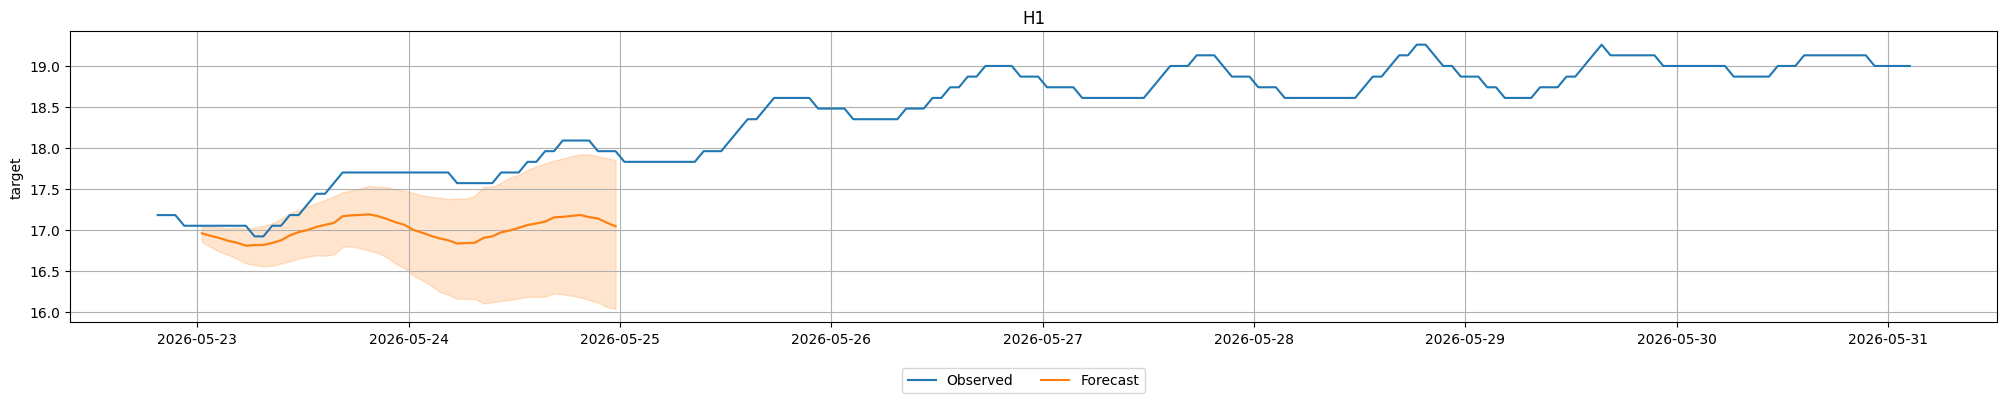

In [20]:
predictions_may = predictor.predict(test_data)
predictions_may.head()

# TimeSeriesDataFrame can also be loaded directly from a file
test_data_full = TimeSeriesDataFrame.from_path("../may.csv")

predictor.plot(test_data_full, predictions_may, quantile_levels=[0.1, 0.9], max_history_length=200)